<a href="https://colab.research.google.com/github/Sachin20010517/demand-forecasting-model/blob/main/smartstockflow_forecasting_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SmartStockFlow — Corrected Hybrid LSTM + XGBoost Demand Forecasting Notebook

This notebook fixes the main issues found in the previous version:

| Area | Fix Applied |
|---|---|
| Time-series handling | Per `Store ID` + `Product ID` chronological splitting and sequence generation |
| Leakage prevention | `Demand Forecast` removed; feature selection happens **after** train/validation/test split |
| Ensemble design | Ridge stacking meta-learner using validation predictions |
| SHAP integration | SHAP explains the XGBoost component only |
| Cross-validation | Entity-safe walk-forward validation |
| Hyperparameter tuning | Validation-based randomized XGBoost tuning |
| Uncertainty estimation | Conformal prediction intervals from validation residuals |
| Production export | Saves `.h5`, `.keras`, `.pkl`, `metadata.json`, and a downloadable ZIP |

**Target variable:** `Units Sold`  
**Prediction meaning:** future retail demand.

---
## 1. Environment Setup
Run the install cell once if you are using Google Colab or a fresh environment.

In [1]:
# Run this cell only when required.
# In Colab, keep it enabled. Locally, you can comment it after installing once.

!pip install -q xgboost shap scikit-learn tensorflow pandas numpy matplotlib seaborn joblib

In [2]:
import os
import json
import random
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.feature_selection import mutual_info_regression, f_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterSampler
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import shap

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False
})

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

TensorFlow: 2.20.0
NumPy: 2.0.2
Pandas: 2.2.2


---
## 2. Data Loading

Expected dataset file:

```text
new-retail_store_inventory.csv
```

Important leakage rule:

- `Units Sold` is the target.
- `Demand Forecast` is **not** used as a feature because it already represents a forecast-like value.
- `Units Ordered` is excluded by default because it may be a decision made after demand planning. If you truly know it before prediction time, you may include it later.

In [3]:
DATA_PATH = "new-retail_store_inventory.csv"

df_raw = pd.read_csv(DATA_PATH)
df_raw["Date"] = pd.to_datetime(df_raw["Date"])

print("=" * 60)
print("DATASET PROFILE")
print("=" * 60)
print(f"Rows        : {len(df_raw):,}")
print(f"Columns     : {df_raw.shape[1]}")
print(f"Date range  : {df_raw['Date'].min().date()} to {df_raw['Date'].max().date()}")
print(f"Stores      : {df_raw['Store ID'].nunique()}")
print(f"Products    : {df_raw['Product ID'].nunique()}")
print()
print(df_raw.head())

DATASET PROFILE
Rows        : 73,100
Columns     : 16
Date range  : 2022-01-01 to 2024-01-01
Stores      : 5
Products    : 20

        Date Store ID Product ID                  Product Name Category  \
0 2022-01-01     S001   PROD-001  Coca-Cola Original 330ml Can   Drinks   
1 2022-01-01     S001   PROD-002        Pepsi Max 500ml Bottle   Drinks   
2 2022-01-01     S001   PROD-003  Lucozade Energy Orange 380ml   Drinks   
3 2022-01-01     S001   PROD-004   Red Bull Energy Drink 250ml   Drinks   
4 2022-01-01     S001   PROD-005      Volvic Still Water 500ml   Drinks   

  Region  Inventory Level  Units Sold  Units Ordered  Demand Forecast  Price  \
0  North              231         127             55           135.47   0.85   
1  South              204         150             66           144.04   1.05   
2   West              102          65             51            74.02   0.95   
3  North              469          61            164            62.18   1.30   
4   East              

In [4]:
print("Columns:")
for col in df_raw.columns:
    print("-", col)

print("\nMissing values:")
display(df_raw.isna().sum())

print("\nTarget summary: Units Sold")
display(df_raw["Units Sold"].describe())

Columns:
- Date
- Store ID
- Product ID
- Product Name
- Category
- Region
- Inventory Level
- Units Sold
- Units Ordered
- Demand Forecast
- Price
- Discount
- Weather Condition
- Holiday/Promotion
- Competitor Pricing
- Seasonality

Missing values:


,0
Date,0
Store ID,0
Product ID,0
Product Name,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Demand Forecast,0



Target summary: Units Sold


,Units Sold
count,73100.000000
mean,136.464870
std,108.919406
min,0.000000
25%,49.000000
50%,107.000000
75%,203.000000
max,499.000000


---
## 3. Data Cleaning

This section performs safe cleaning only. It does **not** use future information.

In [5]:
df = df_raw.copy()

# Standard cleaning
df = df.drop_duplicates()
df = df.sort_values(["Store ID", "Product ID", "Date"]).reset_index(drop=True)

# Basic sanity clipping
df["Discount"] = df["Discount"].clip(lower=0, upper=100)
df["Price"] = df["Price"].clip(lower=0.01)
df["Competitor Pricing"] = df["Competitor Pricing"].clip(lower=0.01)
df["Inventory Level"] = df["Inventory Level"].clip(lower=0)

# Keep target non-negative
df["Units Sold"] = df["Units Sold"].clip(lower=0)

print("Cleaned shape:", df.shape)

Cleaned shape: (73100, 16)


---
## 4. Exploratory Analysis

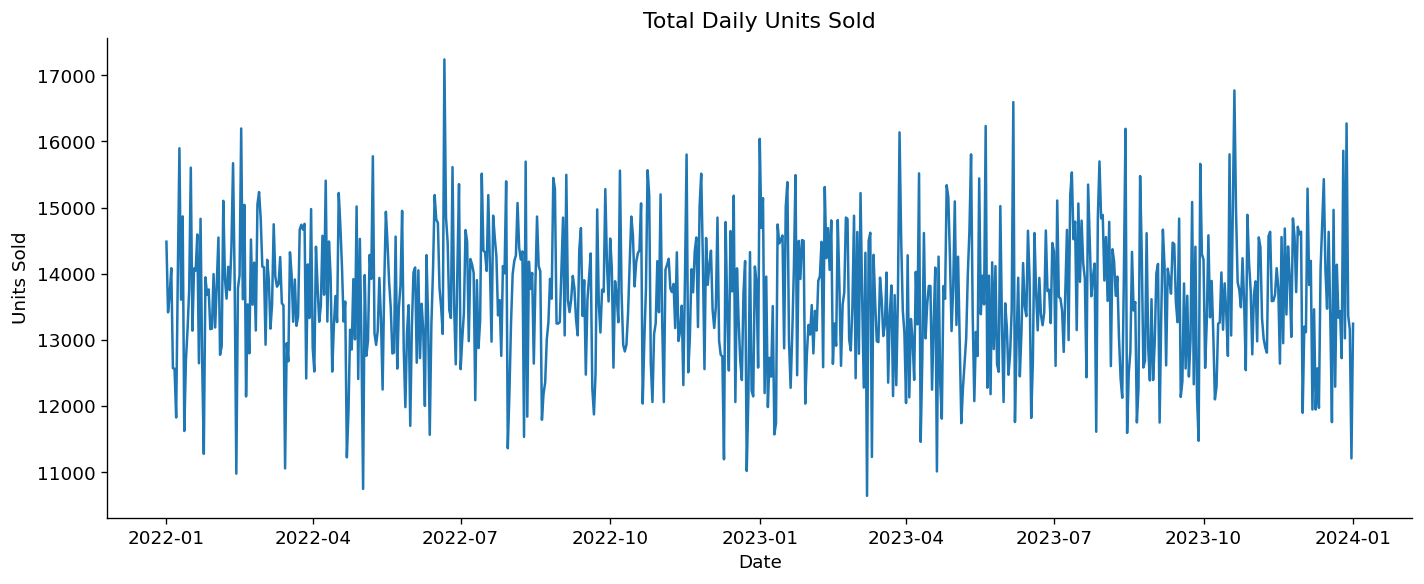

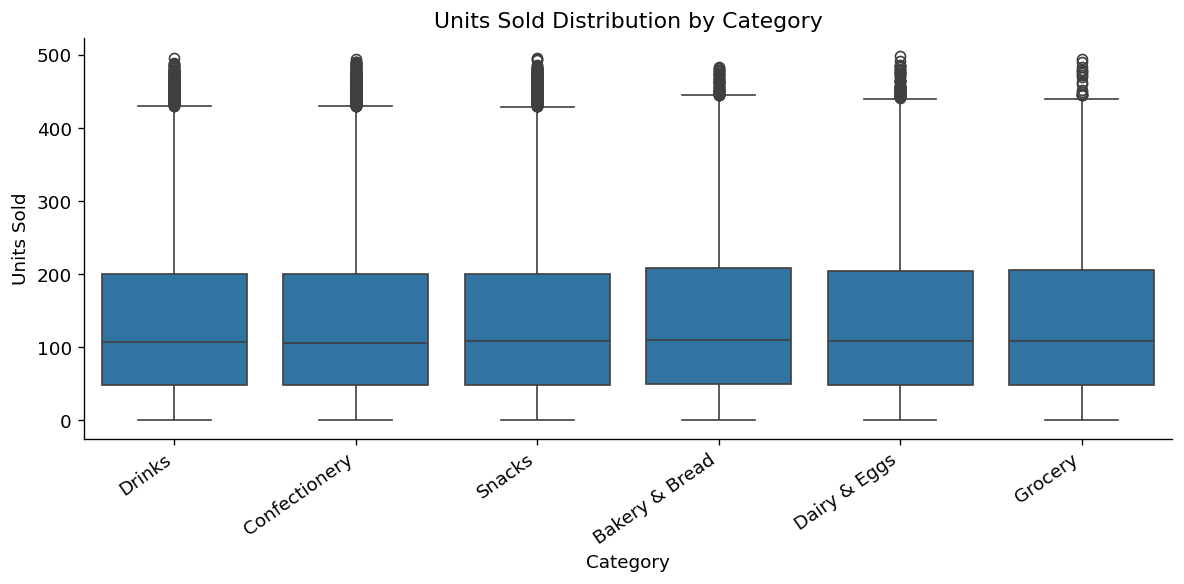

In [6]:
plt.figure(figsize=(12, 5))
daily_sales = df.groupby("Date")["Units Sold"].sum()
plt.plot(daily_sales.index, daily_sales.values)
plt.title("Total Daily Units Sold")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Category", y="Units Sold")
plt.xticks(rotation=35, ha="right")
plt.title("Units Sold Distribution by Category")
plt.tight_layout()
plt.show()

---
## 5. Leakage-Safe Feature Engineering

All lag and rolling features are calculated per:

```text
Store ID + Product ID
```

and use `.shift(1)` so the model only sees past sales, not the current/future target.

In [7]:
TARGET = "Units Sold"
GROUP_COLS = ["Store ID", "Product ID"]

# Lag features
for lag in [1, 2, 3, 7, 14]:
    df[f"Sales_Lag_{lag}"] = df.groupby(GROUP_COLS)[TARGET].shift(lag)

# Rolling features: shift first, then roll
for window in [3, 7, 14, 28]:
    df[f"RollingMean_{window}"] = (
        df.groupby(GROUP_COLS)[TARGET]
          .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )
    df[f"RollingStd_{window}"] = (
        df.groupby(GROUP_COLS)[TARGET]
          .transform(lambda x: x.shift(1).rolling(window, min_periods=1).std().fillna(0))
    )

df["RollingMax_7"] = (
    df.groupby(GROUP_COLS)[TARGET]
      .transform(lambda x: x.shift(1).rolling(7, min_periods=1).max())
)
df["RollingMin_7"] = (
    df.groupby(GROUP_COLS)[TARGET]
      .transform(lambda x: x.shift(1).rolling(7, min_periods=1).min())
)

# Business/context features
df["Effective_Price"] = df["Price"] * (1 - df["Discount"] / 100.0)
df["Price_vs_Competitor"] = df["Price"] / (df["Competitor Pricing"] + 1e-6)
df["Discount_x_Price"] = df["Discount"] * df["Price"]
df["Inv_Sales_Ratio"] = (df["Inventory Level"] / (df["RollingMean_7"] + 1)).clip(upper=50)

# Date features
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["DayOfMonth"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)
df["Year"] = df["Date"].dt.year

# Cyclical encoding
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)
df["DoW_sin"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
df["DoW_cos"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)
df["WoY_sin"] = np.sin(2 * np.pi * df["WeekOfYear"] / 52)
df["WoY_cos"] = np.cos(2 * np.pi * df["WeekOfYear"] / 52)

# Drop first rows that lack lag history
df = df.dropna().reset_index(drop=True)

print("Shape after feature engineering:", df.shape)

Shape after feature engineering: (71700, 48)


---
## 6. Train / Validation / Test Split

This split is performed **before feature selection and encoding**.

Each `Store ID + Product ID` time series is split independently:

- 70% training
- 15% validation
- 15% testing

No random shuffling is used.

In [8]:
SEQ_LEN = 21
MIN_ROWS = SEQ_LEN + 20

train_parts, val_parts, test_parts = [], [], []

for (store_id, product_id), grp in df.groupby(GROUP_COLS):
    grp = grp.sort_values("Date").reset_index(drop=True)
    n = len(grp)

    if n < MIN_ROWS:
        continue

    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    train_parts.append(grp.iloc[:train_end])
    val_parts.append(grp.iloc[train_end:val_end])
    test_parts.append(grp.iloc[val_end:])

train_df = pd.concat(train_parts).reset_index(drop=True)
val_df = pd.concat(val_parts).reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

print(f"Train      : {len(train_df):,}")
print(f"Validation : {len(val_df):,}")
print(f"Test       : {len(test_df):,}")

print("\nDate ranges:")
print("Train:", train_df["Date"].min().date(), "to", train_df["Date"].max().date())
print("Val  :", val_df["Date"].min().date(), "to", val_df["Date"].max().date())
print("Test :", test_df["Date"].min().date(), "to", test_df["Date"].max().date())

Train      : 50,100
Validation : 10,800
Test       : 10,800

Date ranges:
Train: 2022-01-15 to 2023-05-30
Val  : 2023-05-31 to 2023-09-15
Test : 2023-09-16 to 2024-01-01


---
## 7. Feature Definition and Train-Only Encoding

`Demand Forecast` and `Units Ordered` are intentionally excluded.

Why?

- `Demand Forecast` is a forecast-like column and causes target leakage.
- `Units Ordered` may be a replenishment decision made after demand prediction. If it is not known at inference time, it must not be used.

In [9]:
NUMERIC_FEATURES = [
    "Inventory Level",
    "Price",
    "Discount",
    "Competitor Pricing",
    "Holiday/Promotion",
    "Sales_Lag_1",
    "Sales_Lag_2",
    "Sales_Lag_3",
    "Sales_Lag_7",
    "Sales_Lag_14",
    "RollingMean_3",
    "RollingStd_3",
    "RollingMean_7",
    "RollingStd_7",
    "RollingMean_14",
    "RollingStd_14",
    "RollingMean_28",
    "RollingStd_28",
    "RollingMax_7",
    "RollingMin_7",
    "Effective_Price",
    "Price_vs_Competitor",
    "Discount_x_Price",
    "Inv_Sales_Ratio",
    "DayOfWeek",
    "DayOfMonth",
    "Month",
    "Quarter",
    "WeekOfYear",
    "IsWeekend",
    "Year",
    "Month_sin",
    "Month_cos",
    "DoW_sin",
    "DoW_cos",
    "WoY_sin",
    "WoY_cos"
]

CATEGORICAL_FEATURES = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

# Defensive check: these must never enter the model
FORBIDDEN_FEATURES = {"Demand Forecast", "Units Sold", "Units Ordered", "Date", "Product Name"}

for forbidden in FORBIDDEN_FEATURES:
    assert forbidden not in NUMERIC_FEATURES
    assert forbidden not in CATEGORICAL_FEATURES

feature_encoder = ColumnTransformer(
    transformers=[
        ("num", "passthrough", NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES)
    ],
    remainder="drop"
)

X_train_all = feature_encoder.fit_transform(train_df)
X_val_all = feature_encoder.transform(val_df)
X_test_all = feature_encoder.transform(test_df)

encoded_feature_names = list(feature_encoder.get_feature_names_out())

y_train = train_df[TARGET].values
y_val = val_df[TARGET].values
y_test = test_df[TARGET].values

print("Encoded train shape:", X_train_all.shape)
print("Number of encoded features:", len(encoded_feature_names))

Encoded train shape: (50100, 80)
Number of encoded features: 80


---
## 8. Leakage-Safe Feature Selection

Feature selection is performed **only on training data**.

No validation or test rows are used.
No random future/past mixing is used.

In [10]:
# Use the complete training partition or the most recent training rows if very large.
SELECTION_N = min(30000, len(train_df))
X_sel = X_train_all[-SELECTION_N:]
y_sel = y_train[-SELECTION_N:]

mi_scores = mutual_info_regression(X_sel, y_sel, random_state=SEED)
mi_df = pd.DataFrame({"Feature": encoded_feature_names, "MI_Score": mi_scores})
mi_threshold = mi_df["MI_Score"].quantile(0.40)
mi_selected = set(mi_df.loc[mi_df["MI_Score"] >= mi_threshold, "Feature"])

f_scores, f_pvals = f_regression(X_sel, y_sel)
f_df = pd.DataFrame({"Feature": encoded_feature_names, "P_Value": f_pvals})
f_selected = set(f_df.loc[f_df["P_Value"] < 0.05, "Feature"])

lasso_scaler_for_selection = MinMaxScaler()
X_sel_scaled = lasso_scaler_for_selection.fit_transform(X_sel)
lasso = Lasso(alpha=0.001, max_iter=5000, random_state=SEED)
lasso.fit(X_sel_scaled, y_sel)
lasso_selected = set(
    encoded_feature_names[i]
    for i, coef in enumerate(lasso.coef_)
    if abs(coef) > 1e-6
)

vote_map = {
    feature: int(feature in mi_selected) + int(feature in f_selected) + int(feature in lasso_selected)
    for feature in encoded_feature_names
}

selected_features = [feature for feature, votes in vote_map.items() if votes >= 2]

# Always keep core lag/business features if present.
MUST_KEEP_KEYWORDS = [
    "Sales_Lag_1",
    "Sales_Lag_7",
    "RollingMean_7",
    "Inventory Level",
    "Price",
    "Discount",
    "Holiday/Promotion"
]

for feature in encoded_feature_names:
    if any(keyword in feature for keyword in MUST_KEEP_KEYWORDS) and feature not in selected_features:
        selected_features.append(feature)

selected_indices = [encoded_feature_names.index(feature) for feature in selected_features]

X_train = X_train_all[:, selected_indices]
X_val = X_val_all[:, selected_indices]
X_test = X_test_all[:, selected_indices]

print(f"Selected features: {len(selected_features)} / {len(encoded_feature_names)}")
for feature in selected_features:
    print("-", feature)

Selected features: 72 / 80
- num__Inventory Level
- num__Price
- num__Discount
- num__Competitor Pricing
- num__Holiday/Promotion
- num__Sales_Lag_1
- num__Sales_Lag_2
- num__Sales_Lag_3
- num__Sales_Lag_7
- num__Sales_Lag_14
- num__RollingStd_3
- num__RollingMean_7
- num__RollingStd_7
- num__RollingMean_14
- num__RollingStd_14
- num__RollingMean_28
- num__RollingStd_28
- num__RollingMax_7
- num__RollingMin_7
- num__Price_vs_Competitor
- num__Discount_x_Price
- num__Inv_Sales_Ratio
- num__DayOfWeek
- num__DayOfMonth
- num__Month
- num__Quarter
- num__WeekOfYear
- num__IsWeekend
- num__Year
- num__Month_sin
- num__Month_cos
- num__DoW_sin
- num__DoW_cos
- num__WoY_sin
- num__WoY_cos
- cat__Store ID_S004
- cat__Store ID_S005
- cat__Product ID_PROD-001
- cat__Product ID_PROD-002
- cat__Product ID_PROD-003
- cat__Product ID_PROD-004
- cat__Product ID_PROD-005
- cat__Product ID_PROD-006
- cat__Product ID_PROD-007
- cat__Product ID_PROD-008
- cat__Product ID_PROD-009
- cat__Product ID_PROD-0

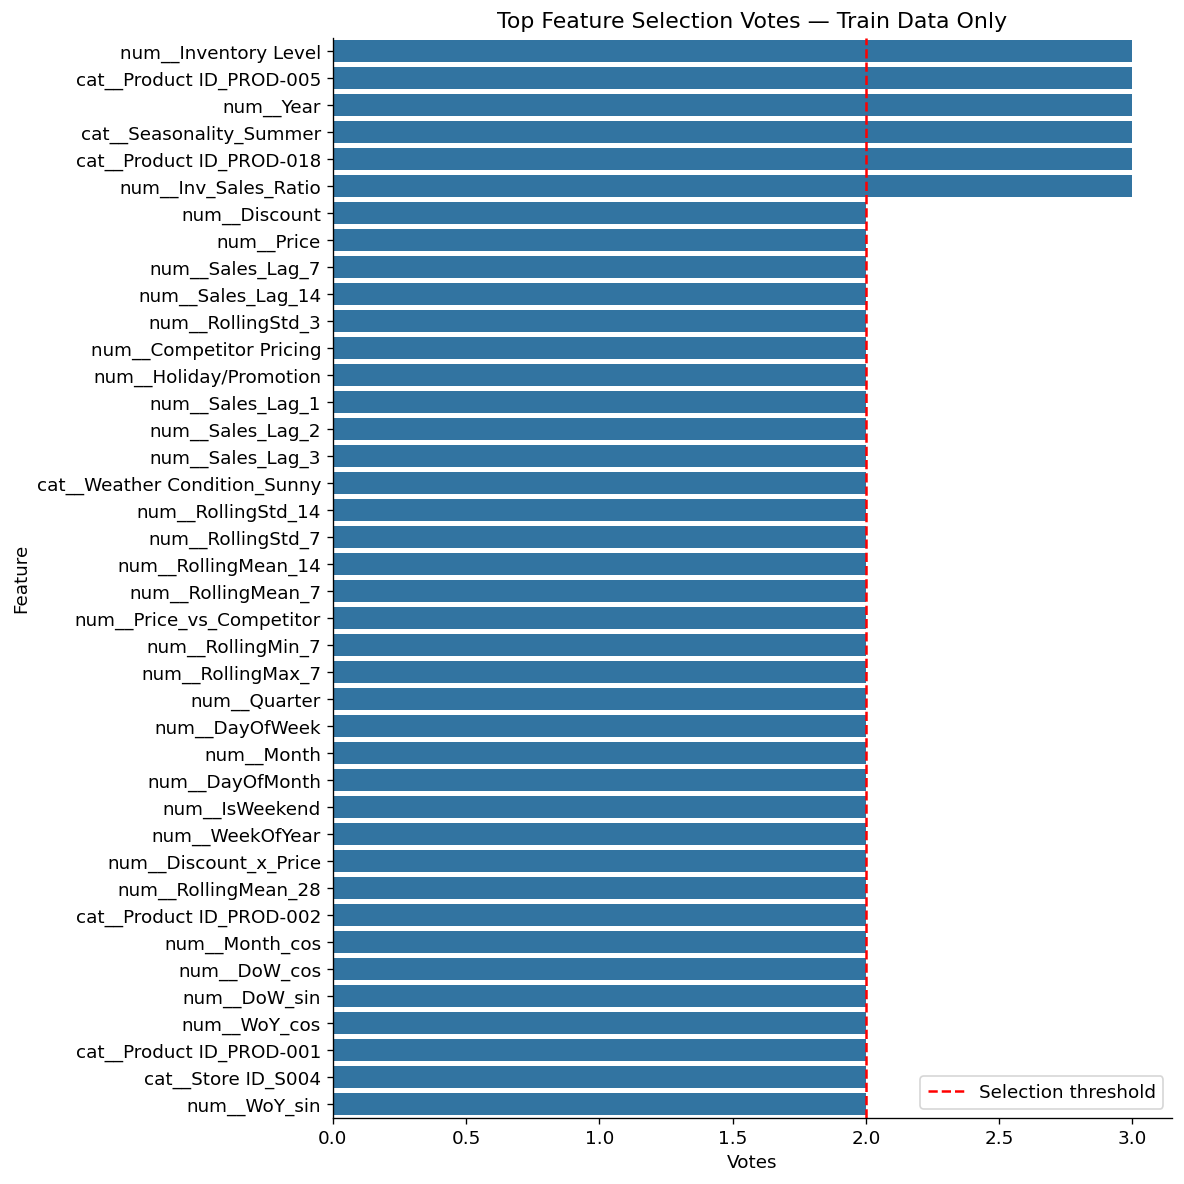

In [11]:
vote_df = pd.DataFrame([
    {"Feature": feature, "Votes": votes}
    for feature, votes in vote_map.items()
]).sort_values("Votes", ascending=False).head(40)

plt.figure(figsize=(10, 10))
sns.barplot(data=vote_df, x="Votes", y="Feature")
plt.axvline(2, color="red", linestyle="--", label="Selection threshold")
plt.title("Top Feature Selection Votes — Train Data Only")
plt.legend()
plt.tight_layout()
plt.show()

---
## 9. Scaling and Sequence Construction

- LSTM receives scaled features and scaled target.
- XGBoost receives raw selected encoded features.
- Sequences are built per `Store ID + Product ID`, so no sequence crosses product/store boundaries.

In [12]:
lstm_feature_scaler = MinMaxScaler()
X_train_lstm_scaled = lstm_feature_scaler.fit_transform(X_train)
X_val_lstm_scaled = lstm_feature_scaler.transform(X_val)
X_test_lstm_scaled = lstm_feature_scaler.transform(X_test)

target_scaler = MinMaxScaler()
y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = target_scaler.transform(y_val.reshape(-1, 1)).ravel()
y_test_scaled = target_scaler.transform(y_test.reshape(-1, 1)).ravel()

print("Scalers fitted on training data only.")

Scalers fitted on training data only.


In [13]:
def build_sequences(df_split, X_scaled, y_scaled, seq_len):
    Xs, ys = [], []

    for _, grp in df_split.groupby(GROUP_COLS):
        positions = grp.index.to_list()

        if len(positions) <= seq_len:
            continue

        X_group = X_scaled[positions]
        y_group = y_scaled[positions]

        for i in range(seq_len, len(positions)):
            Xs.append(X_group[i - seq_len:i])
            ys.append(y_group[i])

    return np.array(Xs), np.array(ys)


def align_tabular_rows(df_split, X_raw, y_raw, seq_len):
    X_out, y_out = [], []

    for _, grp in df_split.groupby(GROUP_COLS):
        positions = grp.index.to_list()

        if len(positions) <= seq_len:
            continue

        X_out.append(X_raw[positions[seq_len:]])
        y_out.append(y_raw[positions[seq_len:]])

    return np.vstack(X_out), np.concatenate(y_out)


X_train_seq, y_train_seq = build_sequences(train_df, X_train_lstm_scaled, y_train_scaled, SEQ_LEN)
X_val_seq, y_val_seq = build_sequences(val_df, X_val_lstm_scaled, y_val_scaled, SEQ_LEN)
X_test_seq, y_test_seq = build_sequences(test_df, X_test_lstm_scaled, y_test_scaled, SEQ_LEN)

X_train_xgb, y_train_xgb = align_tabular_rows(train_df, X_train, y_train, SEQ_LEN)
X_val_xgb, y_val_xgb = align_tabular_rows(val_df, X_val, y_val, SEQ_LEN)
X_test_xgb, y_test_xgb = align_tabular_rows(test_df, X_test, y_test, SEQ_LEN)

y_test_actual = target_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).ravel()

assert len(X_train_seq) == len(X_train_xgb)
assert len(X_val_seq) == len(X_val_xgb)
assert len(X_test_seq) == len(X_test_xgb)

print("LSTM train shape:", X_train_seq.shape)
print("XGB train shape :", X_train_xgb.shape)

LSTM train shape: (48000, 21, 72)
XGB train shape : (48000, 72)


---
## 10. Baseline Models

Baselines are important for academic validity.

In [14]:
def find_feature_index(keyword):
    matches = [i for i, f in enumerate(selected_features) if keyword in f]
    if not matches:
        raise ValueError(f"Feature containing '{keyword}' was not found.")
    return matches[0]

lag1_idx = find_feature_index("Sales_Lag_1")
lag7_idx = find_feature_index("Sales_Lag_7")

naive_preds = X_test_xgb[:, lag1_idx]
seasonal_preds = X_test_xgb[:, lag7_idx]

linear_model = LinearRegression()
linear_model.fit(X_train_xgb, y_train_xgb)
linear_preds = linear_model.predict(X_test_xgb)

print("Naive Lag-1 MAE     :", mean_absolute_error(y_test_actual, naive_preds))
print("Seasonal Lag-7 MAE  :", mean_absolute_error(y_test_actual, seasonal_preds))
print("Linear Regression MAE:", mean_absolute_error(y_test_actual, linear_preds))

Naive Lag-1 MAE     : 119.58781609195402
Seasonal Lag-7 MAE  : 118.98333333333333
Linear Regression MAE: 68.89849724802046


---
## 11. Entity-Safe Walk-Forward Validation

This is stronger than a simple global `TimeSeriesSplit`.

For each fold, every Store+Product series contributes earlier rows to training and later rows to validation.

In [15]:
def build_walk_forward_fold(source_df, ratios=(0.50, 0.65, 0.80), val_window_ratio=0.10):
    folds = []

    for ratio in ratios:
        fold_train_parts, fold_val_parts = [], []

        for _, grp in source_df.groupby(GROUP_COLS):
            grp = grp.sort_values("Date")
            n = len(grp)

            train_end = int(n * ratio)
            val_end = min(n, train_end + max(SEQ_LEN + 5, int(n * val_window_ratio)))

            if train_end <= SEQ_LEN or val_end <= train_end + 2:
                continue

            fold_train_parts.append(grp.iloc[:train_end])
            fold_val_parts.append(grp.iloc[train_end:val_end])

        folds.append((
            pd.concat(fold_train_parts).reset_index(drop=True),
            pd.concat(fold_val_parts).reset_index(drop=True)
        ))

    return folds


def transform_split(split_df):
    X_all = feature_encoder.transform(split_df)
    X = X_all[:, selected_indices]
    y = split_df[TARGET].values
    return X, y


cv_results = []

for fold_idx, (fold_train_df, fold_val_df) in enumerate(build_walk_forward_fold(train_df), start=1):
    X_fold_train, y_fold_train = transform_split(fold_train_df)
    X_fold_val, y_fold_val = transform_split(fold_val_df)

    model = XGBRegressor(
        n_estimators=400,
        learning_rate=0.04,
        max_depth=5,
        min_child_weight=5,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=2.0,
        random_state=SEED,
        objective="reg:squarederror",
        eval_metric="mae",
        verbosity=0
    )

    model.fit(X_fold_train, y_fold_train)
    preds = model.predict(X_fold_val)

    result = {
        "fold": fold_idx,
        "MAE": mean_absolute_error(y_fold_val, preds),
        "RMSE": mean_squared_error(y_fold_val, preds) ** 0.5,
        "R2": r2_score(y_fold_val, preds)
    }
    cv_results.append(result)

cv_df = pd.DataFrame(cv_results)
display(cv_df)
print("Mean CV MAE:", cv_df["MAE"].mean())

,fold,MAE,RMSE,R2
0,1,70.095886,90.168208,0.328529
1,2,70.143715,89.727765,0.315983
2,3,69.330048,88.428715,0.327908


Mean CV MAE: 69.85654958089192


---
## 12. XGBoost Hyperparameter Tuning

The search uses training data for fitting and validation data for model selection.

The test set is not touched.

In [16]:
param_grid = {
    "n_estimators": [400, 600, 800, 1000],
    "learning_rate": [0.02, 0.03, 0.04, 0.05],
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.75, 0.85, 0.95],
    "colsample_bytree": [0.75, 0.85, 0.95],
    "reg_alpha": [0.0, 0.05, 0.1],
    "reg_lambda": [1.0, 2.0, 3.0],
}

search_space = list(ParameterSampler(param_grid, n_iter=12, random_state=SEED))

tuning_results = []
best_xgb_model = None
best_mae = float("inf")
best_params = None

for i, params in enumerate(search_space, start=1):
    model = XGBRegressor(
        **params,
        objective="reg:squarederror",
        eval_metric="mae",
        random_state=SEED,
        verbosity=0
    )

    model.fit(X_train_xgb, y_train_xgb)

    val_preds = model.predict(X_val_xgb)
    mae = mean_absolute_error(y_val_xgb, val_preds)

    tuning_results.append({"trial": i, "MAE": mae, **params})

    if mae < best_mae:
        best_mae = mae
        best_params = params
        best_xgb_model = model

tuning_df = pd.DataFrame(tuning_results).sort_values("MAE")
display(tuning_df.head())

xgb_model = best_xgb_model
xgb_val_preds = xgb_model.predict(X_val_xgb)
xgb_test_preds = xgb_model.predict(X_test_xgb)

print("Best XGBoost params:")
print(best_params)
print("Validation MAE:", mean_absolute_error(y_val_xgb, xgb_val_preds))
print("Test MAE:", mean_absolute_error(y_test_actual, xgb_test_preds))

,trial,MAE,subsample,reg_lambda,reg_alpha,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree
0,1,68.447449,0.75,1.0,0.00,600,5,3,0.03,0.95
10,11,68.491356,0.75,2.0,0.05,600,1,4,0.03,0.95
11,12,68.498978,0.75,3.0,0.00,400,3,6,0.02,0.85
8,9,68.531738,0.95,2.0,0.00,800,3,4,0.02,0.95
1,2,68.558876,0.95,2.0,0.10,1000,7,4,0.02,0.75


Best XGBoost params:
{'subsample': 0.75, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.95}
Validation MAE: 68.44744873046875
Test MAE: 68.98103010243383


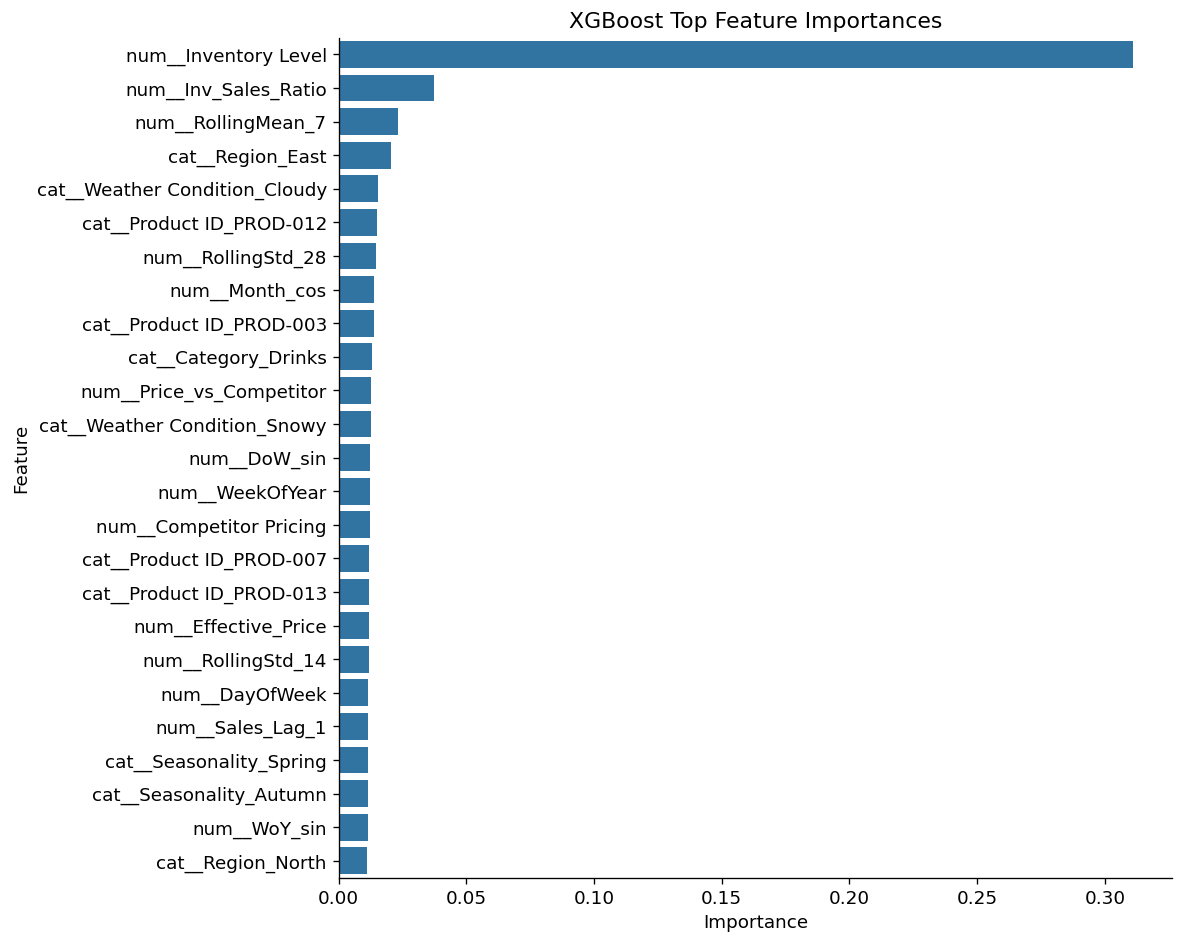

In [17]:
imp_df = (
    pd.DataFrame({
        "Feature": selected_features,
        "Importance": xgb_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .head(25)
)

plt.figure(figsize=(10, 8))
sns.barplot(data=imp_df, x="Importance", y="Feature")
plt.title("XGBoost Top Feature Importances")
plt.tight_layout()
plt.show()

---
## 13. LSTM Model

The LSTM is intentionally moderate in size to reduce overfitting risk on SME-style sparse retail data.

In [18]:
def build_lstm_model(seq_len, n_features):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(seq_len, n_features)),
        BatchNormalization(),
        Dropout(0.25),

        LSTM(32, return_sequences=False),
        BatchNormalization(),
        Dropout(0.20),

        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="huber",
        metrics=["mae"]
    )

    return model


lstm_model = build_lstm_model(SEQ_LEN, X_train_seq.shape[2])
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 21, 64)         │        35,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 21, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 21, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,961 (191.25 KB)

 Trainable params: 48,769 (190.50 KB)

 Non-trainable params: 192 (768.00 B)

In [19]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6, verbose=1),
    ModelCheckpoint("best_lstm.keras", monitor="val_loss", save_best_only=True, verbose=0),
]

history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

lstm_val_scaled = lstm_model.predict(X_val_seq).ravel()
lstm_test_scaled = lstm_model.predict(X_test_seq).ravel()

lstm_val_preds = target_scaler.inverse_transform(lstm_val_scaled.reshape(-1, 1)).ravel()
lstm_test_preds = target_scaler.inverse_transform(lstm_test_scaled.reshape(-1, 1)).ravel()

print("LSTM validation MAE:", mean_absolute_error(y_val_xgb, lstm_val_preds))
print("LSTM test MAE:", mean_absolute_error(y_test_actual, lstm_test_preds))

Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 0.0544 - mae: 0.2526 - val_loss: 0.0258 - val_mae: 0.1779 - learning_rate: 0.0010
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0277 - mae: 0.1898 - val_loss: 0.0257 - val_mae: 0.1932 - learning_rate: 0.0010
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0256 - mae: 0.1837 - val_loss: 0.0302 - val_mae: 0.2158 - learning_rate: 0.0010
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0251 - mae: 0.1822 - val_loss: 0.0316 - val_mae: 0.2205 - learning_rate: 0.0010
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0246 - mae: 0.1808 - val_loss: 0.0246 - val_mae: 0.1863 - learning_rate: 0.0010
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0247 - mae: 0.1811 - val_loss: 0.0243 - val_mae: 0.1827 - learning_rate: 0.0010
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0249 - mae: 0.1818 - val_loss: 0.0400 - val_mae: 0.2506 - learning_rate

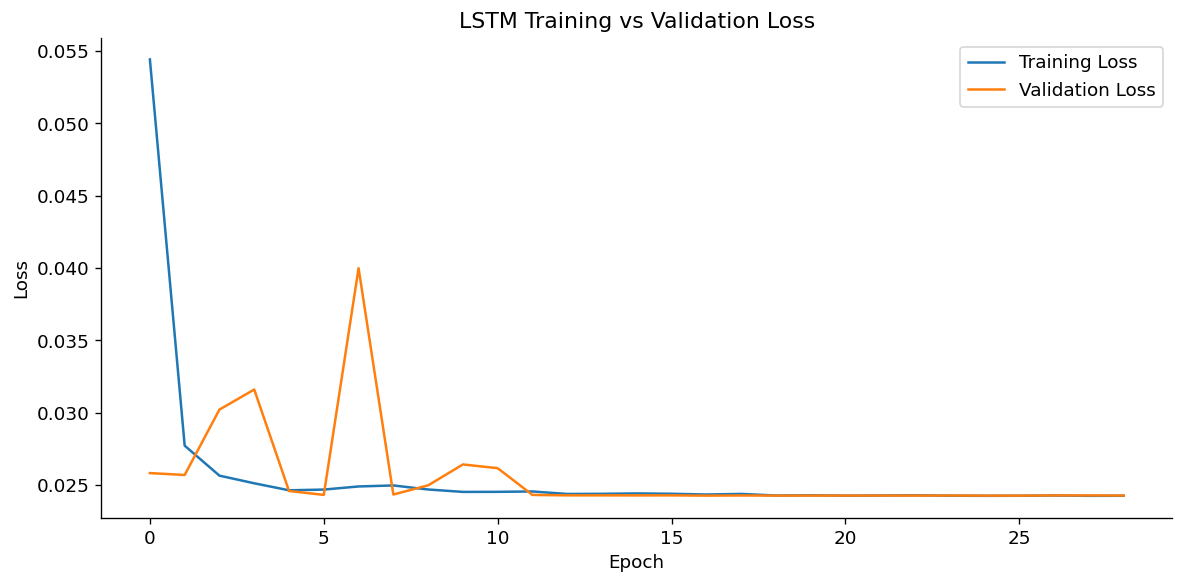

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

---
## 14. Hybrid Ensemble — Ridge Stacking

The meta-learner is trained on validation predictions only.

Inputs to meta-learner:

- LSTM prediction
- XGBoost prediction
- Lag-1 naive baseline
- Lag-7 seasonal baseline

In [21]:
# Validation baseline predictions
val_lag1 = X_val_xgb[:, lag1_idx]
val_lag7 = X_val_xgb[:, lag7_idx]

test_lag1 = X_test_xgb[:, lag1_idx]
test_lag7 = X_test_xgb[:, lag7_idx]

stack_val = np.column_stack([
    lstm_val_preds,
    xgb_val_preds,
    val_lag1,
    val_lag7
])

stack_test = np.column_stack([
    lstm_test_preds,
    xgb_test_preds,
    test_lag1,
    test_lag7
])

meta_learner = Ridge(alpha=1.0)
meta_learner.fit(stack_val, y_val_xgb)

ensemble_test_preds = meta_learner.predict(stack_test)
ensemble_test_preds = np.clip(ensemble_test_preds, 0, None)

print("Meta learner coefficients:")
print({
    "LSTM": meta_learner.coef_[0],
    "XGBoost": meta_learner.coef_[1],
    "Lag1": meta_learner.coef_[2],
    "Lag7": meta_learner.coef_[3],
})

print("Hybrid ensemble test MAE:", mean_absolute_error(y_test_actual, ensemble_test_preds))

Meta learner coefficients:
{'LSTM': np.float64(0.22775019847119396), 'XGBoost': np.float64(0.9977633075930381), 'Lag1': np.float64(-0.009884301417272619), 'Lag7': np.float64(0.00536360552147963)}
Hybrid ensemble test MAE: 68.98810625795115


---
## 15. Uncertainty Estimation

This notebook uses a simple conformal-style residual interval:

```text
prediction interval = prediction ± quantile(|validation residuals|)
```

This gives a practical uncertainty range for demand forecasts.

In [22]:
ensemble_val_preds = meta_learner.predict(stack_val)
validation_abs_errors = np.abs(y_val_xgb - ensemble_val_preds)

CONFIDENCE_LEVEL = 0.90
error_quantile = np.quantile(validation_abs_errors, CONFIDENCE_LEVEL)

test_lower = np.clip(ensemble_test_preds - error_quantile, 0, None)
test_upper = ensemble_test_preds + error_quantile

print(f"{int(CONFIDENCE_LEVEL * 100)}% conformal error quantile: {error_quantile:.2f}")

90% conformal error quantile: 150.62


---
## 16. Evaluation Metrics

In [23]:
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.where(denominator == 0, 0, np.abs(y_true - y_pred) / denominator)) * 100


def wmape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100


def mape_safe(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
        "MAPE": mape_safe(y_true, y_pred),
        "SMAPE": smape(y_true, y_pred),
        "WMAPE": wmape(y_true, y_pred)
    }


results = [
    evaluate_model("Naive Lag-1", y_test_actual, naive_preds),
    evaluate_model("Seasonal Lag-7", y_test_actual, seasonal_preds),
    evaluate_model("Linear Regression", y_test_actual, linear_preds),
    evaluate_model("XGBoost", y_test_actual, xgb_test_preds),
    evaluate_model("LSTM", y_test_actual, lstm_test_preds),
    evaluate_model("Hybrid Ensemble", y_test_actual, ensemble_test_preds),
]

results_df = pd.DataFrame(results).sort_values("MAE")
display(results_df)

,Model,MAE,MSE,RMSE,R2,MAPE,SMAPE,WMAPE
2,Linear Regression,68.898497,7706.839088,87.788605,0.337944,233.511392,58.114934,50.294629
3,XGBoost,68.981030,7740.343031,87.979219,0.335066,238.010773,57.916185,50.354877
5,Hybrid Ensemble,68.988106,7743.318623,87.996128,0.334810,238.829405,57.883789,50.360042
4,LSTM,88.695383,11657.042479,107.967784,-0.001398,340.407641,71.475395,64.745990
1,Seasonal Lag-7,118.983333,23176.890460,152.239582,-0.991010,354.162128,92.754832,86.855634
0,Naive Lag-1,119.587816,23402.060230,152.977319,-1.010353,368.031063,92.699403,87.296895


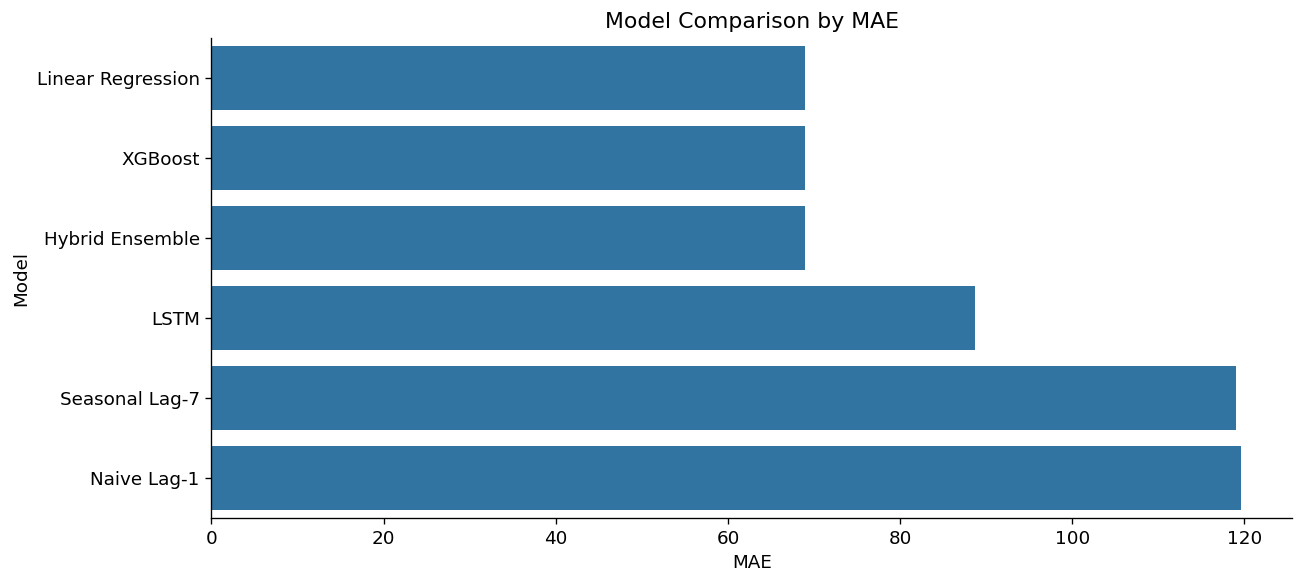

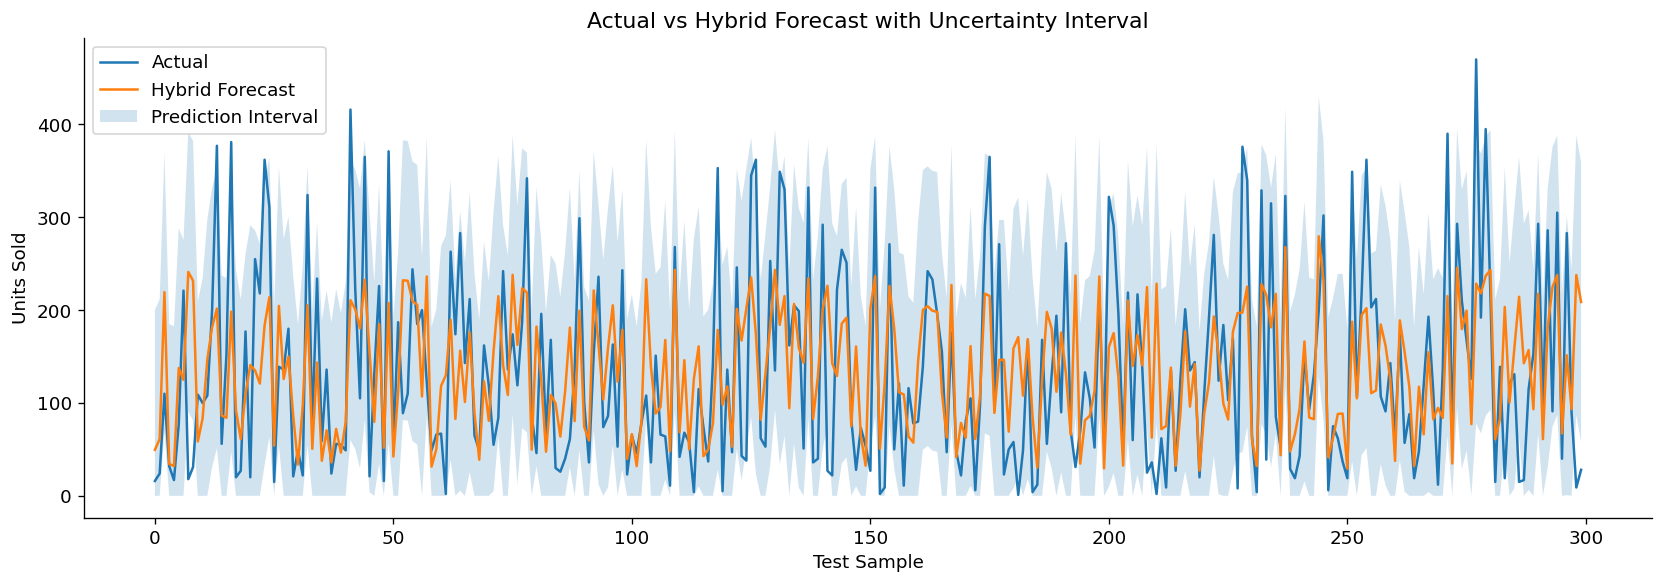

In [24]:
plt.figure(figsize=(11, 5))
sns.barplot(data=results_df, x="MAE", y="Model")
plt.title("Model Comparison by MAE")
plt.tight_layout()
plt.show()

sample_n = min(300, len(y_test_actual))

plt.figure(figsize=(14, 5))
plt.plot(y_test_actual[:sample_n], label="Actual", linewidth=1.5)
plt.plot(ensemble_test_preds[:sample_n], label="Hybrid Forecast", linewidth=1.5)
plt.fill_between(
    np.arange(sample_n),
    test_lower[:sample_n],
    test_upper[:sample_n],
    alpha=0.20,
    label="Prediction Interval"
)
plt.title("Actual vs Hybrid Forecast with Uncertainty Interval")
plt.xlabel("Test Sample")
plt.ylabel("Units Sold")
plt.legend()
plt.tight_layout()
plt.show()

---
## 17. SHAP Explainability for XGBoost

Important academic note:

> SHAP is applied to the XGBoost component. It does not fully explain the LSTM or the full hybrid ensemble unless an additional ensemble-level explainer is implemented.

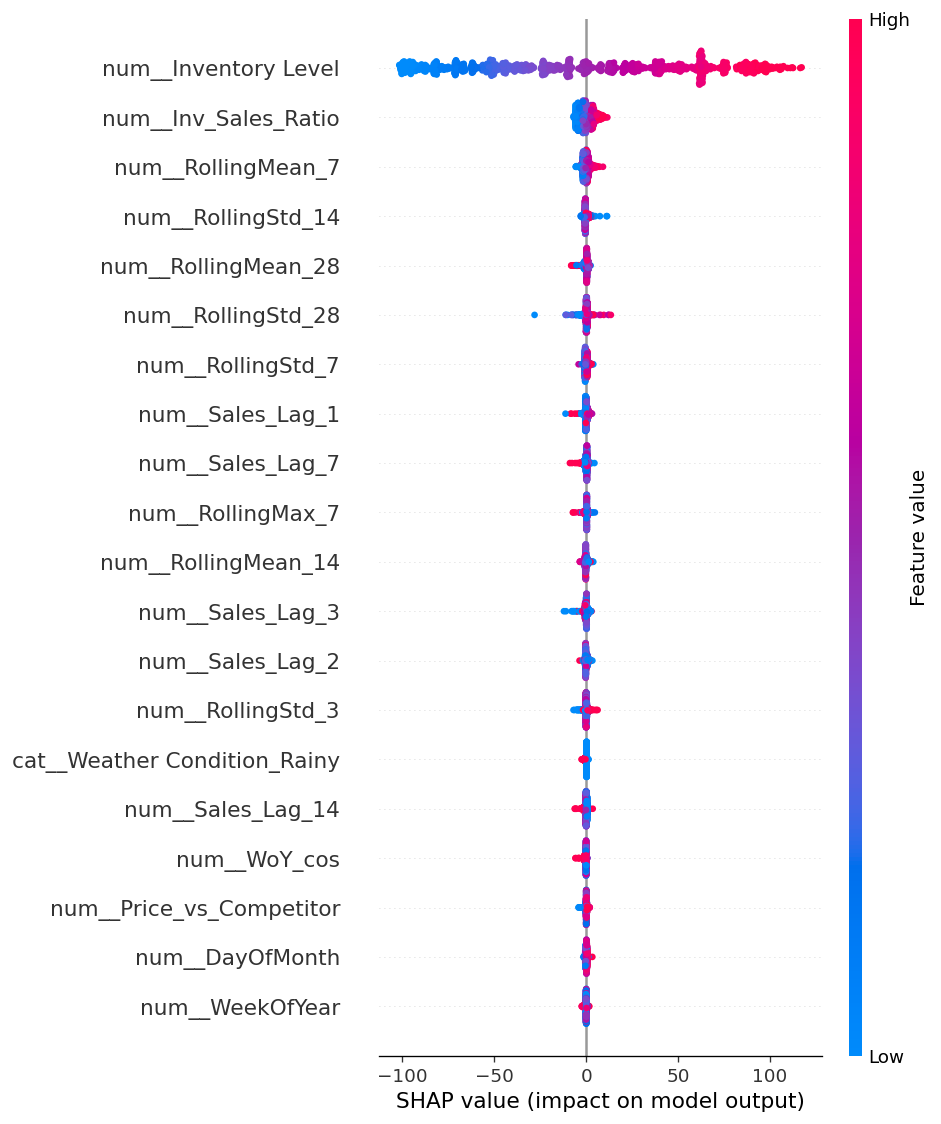

In [25]:
# Use a manageable sample for SHAP
SHAP_SAMPLE = min(1000, len(X_test_xgb))
X_shap = X_test_xgb[:SHAP_SAMPLE]

explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_shap)

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=selected_features,
    show=True
)

In [26]:
# Local explanation for one test prediction
example_idx = 0
shap_contrib = pd.DataFrame({
    "Feature": selected_features,
    "SHAP Impact": shap_values.values[example_idx]
}).sort_values("SHAP Impact", key=np.abs, ascending=False).head(10)

display(shap_contrib)

print("Actual demand:", y_test_actual[example_idx])
print("Hybrid prediction:", ensemble_test_preds[example_idx])
print("Lower interval:", test_lower[example_idx])
print("Upper interval:", test_upper[example_idx])

,Feature,SHAP Impact
0,num__Inventory Level,-77.236504
21,num__Inv_Sales_Ratio,-3.532349
5,num__Sales_Lag_1,-2.199150
33,num__WoY_sin,-1.249293
14,num__RollingStd_14,1.148107
17,num__RollingMax_7,-1.104341
13,num__RollingMean_14,-0.961707
31,num__DoW_sin,-0.656675
12,num__RollingStd_7,0.594192
23,num__DayOfMonth,-0.386208


Actual demand: 16.0
Hybrid prediction: 49.53298111135295
Lower interval: 0.0
Upper interval: 200.1566124593295


---
## 18. Recursive Future Forecast Example

This section forecasts a future date range for a single product using business/context inputs.

The model uses the latest historical rows for the selected product to seed lag and rolling features.

Recursive forecasting note:

> Multi-step recursive forecasts use previous predictions as future lag values. This is realistic, but errors may accumulate over longer horizons.

In [27]:
# ---- configure your forecast here -------------------------------------------
PRODUCT_ID = "PROD-001"
STORE_ID = "S001"

FROM_DATE = "2026-05-01"
TO_DATE = "2026-05-31"

PRICE = 0.85
DISCOUNT = 10
INVENTORY = 300

WEATHER = "Rainy"       # Sunny / Rainy / Cloudy / Snowy
REGION = "North"        # North / South / East / West
CATEGORY = "Drinks"     # Drinks / Snacks / Confectionery / Bakery & Bread / Dairy & Eggs / Grocery
SEASONALITY = "Autumn"  # Spring / Summer / Autumn / Winter
HOLIDAY = 0             # 0 or 1
# ----------------------------------------------------------------------------

In [28]:
def build_future_forecast(
    history_df,
    product_id,
    store_id,
    from_date,
    to_date,
    price,
    discount,
    inventory,
    weather,
    region,
    category,
    seasonality,
    holiday
):
    product_history = (
        history_df[
            (history_df["Product ID"] == product_id) &
            (history_df["Store ID"] == store_id)
        ]
        .sort_values("Date")
        .copy()
    )

    if len(product_history) < 28:
        raise ValueError("Not enough historical rows for recursive forecasting.")

    future_dates = pd.date_range(from_date, to_date)
    sales_history = product_history[TARGET].tolist()

    future_rows = []

    for current_date in future_dates:
        recent = pd.Series(sales_history)

        row = {
            "Date": current_date,
            "Store ID": store_id,
            "Product ID": product_id,
            "Category": category,
            "Region": region,
            "Inventory Level": inventory,
            "Price": price,
            "Discount": discount,
            "Weather Condition": weather,
            "Holiday/Promotion": holiday,
            "Competitor Pricing": product_history["Competitor Pricing"].iloc[-1],
            "Seasonality": seasonality,
        }

        for lag in [1, 2, 3, 7, 14]:
            row[f"Sales_Lag_{lag}"] = sales_history[-lag] if len(sales_history) >= lag else sales_history[-1]

        for window in [3, 7, 14, 28]:
            window_sales = recent.iloc[-window:]
            row[f"RollingMean_{window}"] = window_sales.mean()
            row[f"RollingStd_{window}"] = window_sales.std() if len(window_sales) > 1 else 0

        row["RollingMax_7"] = recent.iloc[-7:].max()
        row["RollingMin_7"] = recent.iloc[-7:].min()

        row["Effective_Price"] = price * (1 - discount / 100.0)
        row["Price_vs_Competitor"] = price / (row["Competitor Pricing"] + 1e-6)
        row["Discount_x_Price"] = discount * price
        row["Inv_Sales_Ratio"] = min(inventory / (row["RollingMean_7"] + 1), 50)

        row["DayOfWeek"] = current_date.dayofweek
        row["DayOfMonth"] = current_date.day
        row["Month"] = current_date.month
        row["Quarter"] = current_date.quarter
        row["WeekOfYear"] = int(current_date.isocalendar().week)
        row["IsWeekend"] = int(row["DayOfWeek"] >= 5)
        row["Year"] = current_date.year
        row["Month_sin"] = np.sin(2 * np.pi * row["Month"] / 12)
        row["Month_cos"] = np.cos(2 * np.pi * row["Month"] / 12)
        row["DoW_sin"] = np.sin(2 * np.pi * row["DayOfWeek"] / 7)
        row["DoW_cos"] = np.cos(2 * np.pi * row["DayOfWeek"] / 7)
        row["WoY_sin"] = np.sin(2 * np.pi * row["WeekOfYear"] / 52)
        row["WoY_cos"] = np.cos(2 * np.pi * row["WeekOfYear"] / 52)

        temp_df = pd.DataFrame([row])
        encoded = feature_encoder.transform(temp_df)[:, selected_indices]
        xgb_pred = xgb_model.predict(encoded)[0]

        # For future LSTM input, use last SEQ_LEN rows + current row approximation
        # This keeps the same selected feature structure.
        scaled_current = lstm_feature_scaler.transform(encoded)
        if len(future_rows) == 0:
            hist_encoded = feature_encoder.transform(product_history.tail(SEQ_LEN))[:, selected_indices]
            hist_scaled = lstm_feature_scaler.transform(hist_encoded)
            lstm_seq = hist_scaled.reshape(1, SEQ_LEN, -1)
        else:
            # Simplified recursive update: use historical scaled sequence with the newest feature row rolled in.
            hist_scaled = np.vstack([hist_scaled[1:], scaled_current])
            lstm_seq = hist_scaled.reshape(1, SEQ_LEN, -1)

        lstm_scaled_pred = lstm_model.predict(lstm_seq, verbose=0).ravel()[0]
        lstm_pred = target_scaler.inverse_transform([[lstm_scaled_pred]])[0][0]

        lag1_pred = row["Sales_Lag_1"]
        lag7_pred = row["Sales_Lag_7"]

        stack_input = np.array([[lstm_pred, xgb_pred, lag1_pred, lag7_pred]])
        ensemble_pred = float(np.clip(meta_learner.predict(stack_input)[0], 0, None))

        lower = max(0, ensemble_pred - error_quantile)
        upper = ensemble_pred + error_quantile

        row["LSTM_Forecast"] = lstm_pred
        row["XGBoost_Forecast"] = xgb_pred
        row["Ensemble_Forecast"] = ensemble_pred
        row["Forecast_Lower"] = lower
        row["Forecast_Upper"] = upper

        future_rows.append(row)

        # Recursive update: predicted demand becomes available as lag for the next day.
        sales_history.append(ensemble_pred)

    return pd.DataFrame(future_rows)


forecast_df = build_future_forecast(
    history_df=df,
    product_id=PRODUCT_ID,
    store_id=STORE_ID,
    from_date=FROM_DATE,
    to_date=TO_DATE,
    price=PRICE,
    discount=DISCOUNT,
    inventory=INVENTORY,
    weather=WEATHER,
    region=REGION,
    category=CATEGORY,
    seasonality=SEASONALITY,
    holiday=HOLIDAY
)

display(forecast_df[[
    "Date",
    "Ensemble_Forecast",
    "Forecast_Lower",
    "Forecast_Upper",
    "LSTM_Forecast",
    "XGBoost_Forecast"
]].head())

,Date,Ensemble_Forecast,Forecast_Lower,Forecast_Upper,LSTM_Forecast,XGBoost_Forecast
0,2026-05-01,150.446280,0.0,301.069911,139.125307,149.477112
1,2026-05-02,149.550262,0.0,300.173893,139.102336,148.872116
2,2026-05-03,146.201635,0.0,296.825267,139.146327,146.190521
3,2026-05-04,142.366934,0.0,292.990565,139.179187,141.763611
4,2026-05-05,139.244026,0.0,289.867658,139.162661,139.341324


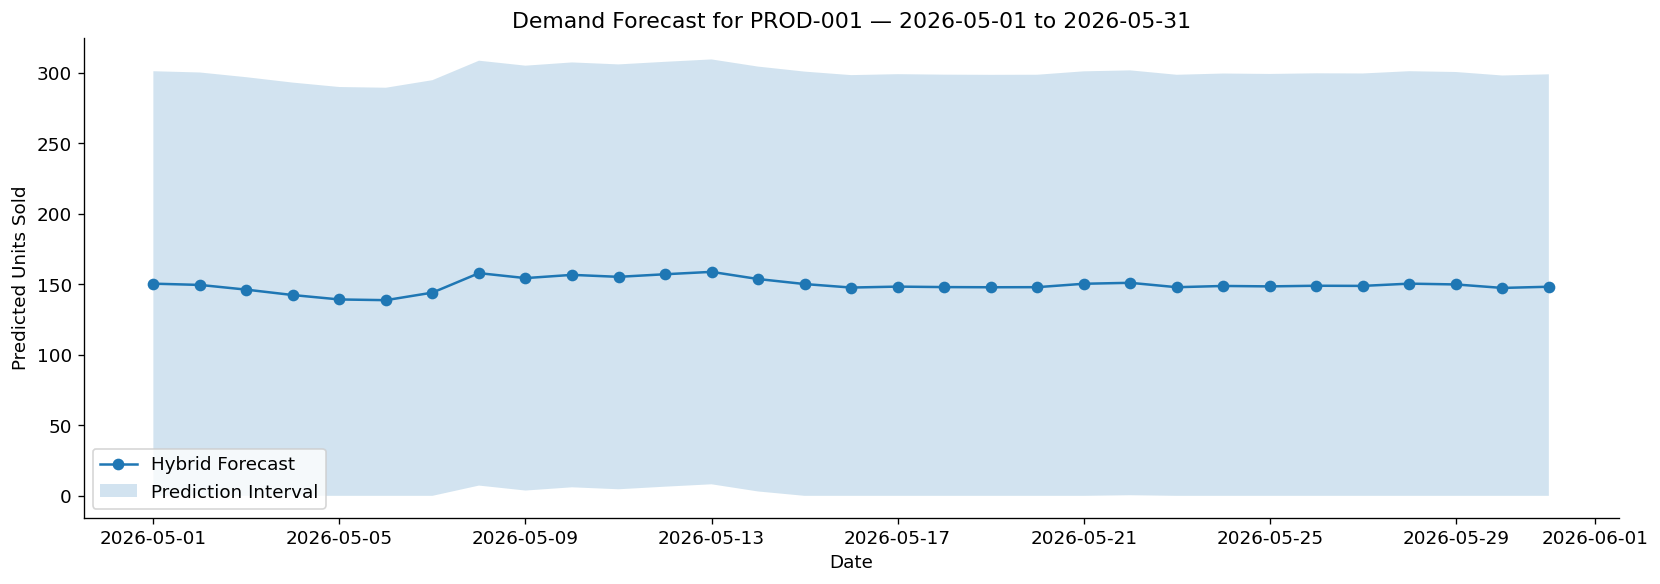

Total forecasted demand: 4635.163002622446
Average daily demand: 149.52138718136922
Peak forecast day:


,12
Date,2026-05-13 00:00:00
Ensemble_Forecast,158.811692


In [29]:
plt.figure(figsize=(14, 5))
plt.plot(forecast_df["Date"], forecast_df["Ensemble_Forecast"], label="Hybrid Forecast", marker="o")
plt.fill_between(
    forecast_df["Date"],
    forecast_df["Forecast_Lower"],
    forecast_df["Forecast_Upper"],
    alpha=0.20,
    label="Prediction Interval"
)
plt.title(f"Demand Forecast for {PRODUCT_ID} — {FROM_DATE} to {TO_DATE}")
plt.xlabel("Date")
plt.ylabel("Predicted Units Sold")
plt.legend()
plt.tight_layout()
plt.show()

print("Total forecasted demand:", forecast_df["Ensemble_Forecast"].sum())
print("Average daily demand:", forecast_df["Ensemble_Forecast"].mean())
print("Peak forecast day:")
display(forecast_df.loc[forecast_df["Ensemble_Forecast"].idxmax(), ["Date", "Ensemble_Forecast"]])

---
## 19. Export Models for Flask Forecast Service

This section saves all production artifacts needed by your Flask app.

Expected Flask destination:

```text
forecast-service/app/models/
```

The notebook also creates a ZIP:

```text
smartstockflow_model_artifacts.zip
```

In [30]:
SAVE_DIR = Path("saved_models")
SAVE_DIR.mkdir(exist_ok=True)

# Save neural network model
lstm_model.save(SAVE_DIR / "lstm_model.h5")
lstm_model.save(SAVE_DIR / "lstm_model.keras")

# Save tree/ensemble models
joblib.dump(xgb_model, SAVE_DIR / "xgboost_model.pkl")
joblib.dump(meta_learner, SAVE_DIR / "ensemble_model.pkl")

# Save preprocessing artifacts
joblib.dump(feature_encoder, SAVE_DIR / "encoder.pkl")
joblib.dump(lstm_feature_scaler, SAVE_DIR / "scaler.pkl")
joblib.dump(target_scaler, SAVE_DIR / "target_scaler.pkl")

# Save feature metadata
metadata = {
    "project": "SmartStockFlow",
    "target": TARGET,
    "model_name": "Hybrid LSTM-XGBoost Ensemble",
    "model_version": "v1.0",
    "sequence_length": SEQ_LEN,
    "confidence_level": CONFIDENCE_LEVEL,
    "conformal_error_quantile": float(error_quantile),
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "encoded_feature_names": encoded_feature_names,
    "selected_features": selected_features,
    "selected_indices": selected_indices,
    "forbidden_features": sorted(list(FORBIDDEN_FEATURES)),
    "best_xgboost_params": best_params,
    "training_rows": int(len(train_df)),
    "validation_rows": int(len(val_df)),
    "test_rows": int(len(test_df))
}

with open(SAVE_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved artifacts:")
for path in sorted(SAVE_DIR.iterdir()):
    print("-", path)

Saved artifacts:
- saved_models/encoder.pkl
- saved_models/ensemble_model.pkl
- saved_models/lstm_model.h5
- saved_models/lstm_model.keras
- saved_models/metadata.json
- saved_models/scaler.pkl
- saved_models/target_scaler.pkl
- saved_models/xgboost_model.pkl


In [32]:
# Create one downloadable ZIP file containing all model artifacts.
import zipfile

ARTIFACT_ZIP = "smartstockflow_model_artifacts.zip"

with zipfile.ZipFile(ARTIFACT_ZIP, "w", zipfile.ZIP_DEFLATED) as zipf:
    for path in SAVE_DIR.iterdir():
        zipf.write(path, arcname=path.name)

print("Created:", ARTIFACT_ZIP)

# If running in Google Colab, uncomment this to download automatically.
# from google.colab import files
# files.download(ARTIFACT_ZIP)

Created: smartstockflow_model_artifacts.zip


---
## 20. Flask Integration Notes

Copy the exported files into:

```text
forecast-service/app/models/
```

Required files:

```text
lstm_model.h5
xgboost_model.pkl
ensemble_model.pkl
encoder.pkl
scaler.pkl
target_scaler.pkl
metadata.json
```

Your Flask service should load these files once during startup, not per request.